# Implementation of the QRC trial and error

Loading data from file


(array([720000., 740000., 760000., 780000., 800000., 820000., 840000.,
        860000.]),
 [Text(720000.0, 0, '720000'),
  Text(740000.0, 0, '740000'),
  Text(760000.0, 0, '760000'),
  Text(780000.0, 0, '780000'),
  Text(800000.0, 0, '800000'),
  Text(820000.0, 0, '820000'),
  Text(840000.0, 0, '840000'),
  Text(860000.0, 0, '860000')])

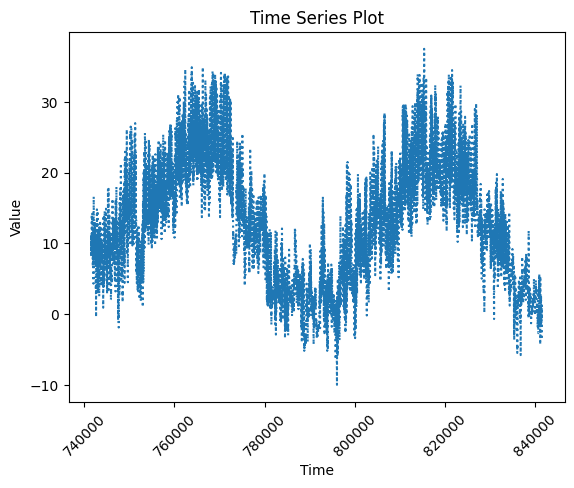

In [38]:
import numpy as np
from matplotlib import pyplot as plt
import os.path

from qreservoir.encoders import CHEEncoder
from qreservoir.models import RCModel
from qreservoir.reservoirs import CNOTReservoir
from sklearn.linear_model import LinearRegression

from src.data.loading.configs import MODEL_DIR_QRC
# ---- load data ----
from src.data.loading.geosphere import Geosphere

data = Geosphere().load_data_into_memory()

data_set_size = 100000
historically_relevant_data = data[-data_set_size:]

plt.plot(historically_relevant_data.index, historically_relevant_data['tl'], linestyle = 'dotted')

# Add title and axis labels
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation=45)

In [39]:
# ---- select data ----

import pandas as pd

selected_columns = [
    'cglo'
    , 'chim'
    , 'dd'
    , 'ddx'
    , 'ff'
#    , 'ffam_flag'
    , 'ffx'
    , 'p'
#    , 'pred'
    , 'rf'
    , 'rr'
    , 'rrm'
    , 'sh'
    , 'so'
    , 'tb10'
    , 'tb20'
    , 'tb50'
    , 'tl'
    , 'tlmax'
    , 'tlmin'
    , 'ts'
    , 'tsmax'
    , 'tsmin'
    , 'zeitx'
    , 'timestamps'
#    , 'stationId'
]

usable_data = historically_relevant_data.dropna(axis="columns", how="all")

final_data_columns = usable_data.columns.intersection(selected_columns)

final_data = historically_relevant_data[final_data_columns].reset_index(drop=True)
final_data.set_index(pd.to_datetime(final_data['timestamps'], format="ISO8601"))
final_data.index.freq = '10min'
final_data.drop('timestamps', axis="columns", inplace=True)

# output
print("Selected columns: {}".format(selected_columns))
print("Usable columns: {}".format(usable_data.columns))
print("Realised columns: {}".format(final_data_columns))
print("Final data dimensions: {}".format(final_data.shape))
print(any(final_data.isna()))


import pmdarima as pa
filtered_data = final_data['tl']
train, test = pa.model_selection.train_test_split(filtered_data, test_size=0.2)

Selected columns: ['cglo', 'chim', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'sh', 'so', 'tb10', 'tb20', 'tb50', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps']
Usable columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffam_flag', 'ffx', 'p', 'pred', 'rf', 'rr',
       'rrm', 'so', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx',
       'timestamps', 'stationId'],
      dtype='object')
Realised columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'so', 'tl',
       'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps'],
      dtype='object')
Final data dimensions: (100000, 17)
True


In [40]:
# ---- base model that produces any result ----
from qulacs import Observable
import qreservoir.encoders as qe

# author info (citation)
# Source code: XYZ

# reload/select best model
file = MODEL_DIR_QRC / "QRC_model.pkl"

# create model
my_encoder = qe.CHEEncoder(feature_num=1)
my_encoder.print_circuit()

my_reservoir = CNOTReservoir(my_encoder,
                             ancilla_num=1,
                             depth=1)
my_observables = [Observable(1) for _ in range(1)]
QRC_model = RCModel(reservoir=my_reservoir,
                    observables=my_observables,
                    subestimator=LinearRegression())


   ___   
  |RX |  
--|   |--
  |___|  


Mean error: 7.218187120175095
Standard deviation: 8.623967877643375


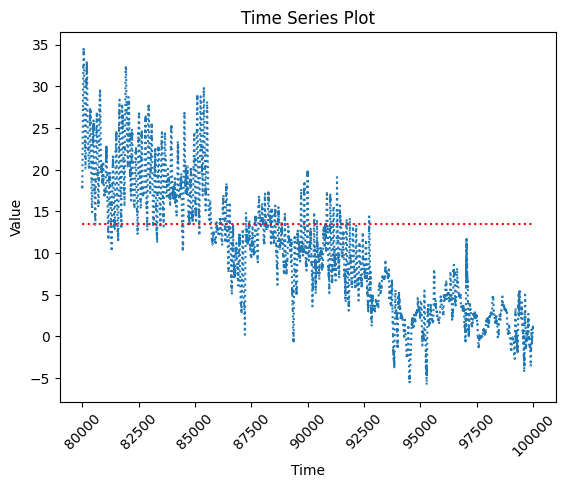

Mean error: 6.965234959793091
Standard deviation: 7.713226141431567


(array([[13.4822216 ],
        [13.4822216 ],
        [13.48222256],
        ...,
        [13.48413181],
        [13.48413181],
        [13.48413181]], shape=(20000, 1)),
 np.float64(6.965234959793091),
 np.float64(7.713226141431567))

In [46]:
# evaluate model
def evaluate_model(model, train_data, test_data):
    train_array, test_array = train_data.to_numpy().reshape(-1,1), test_data.to_numpy().reshape(-1,1)
    model.fit(train_array)
    #MM20260412: plt.plot(train_data.index, train_data, linestyle = 'dotted')

    # --------------------------------------------------------------------------------------
    # visual assessment of goodness of fit
    # in-sample prediction
    all_predictions = model.predict(filtered_data.to_numpy().reshape(-1,1), additional_samples=0)       # 0 gives prediction for each input, i.e., one-step predictions
    in_sample_predictions = all_predictions[:train_data.index[-1]]
    out_of_sample_predictions = all_predictions[train_data.index[-1]:test_data.index[-1]]

    #MM20260412: plt.plot(train_data.index[1:], in_sample_predictions, linestyle = 'dotted', color='red')

    # Add title and axis labels
    plt.title('Time Series Plot')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xticks(rotation=45)

    # -> very crude estimate!
    # --------------------------------------------------------------------------------------
    # --------------------------------------------------------------------------------------
    # calculate average prediction error of in-sample-predictions (make this a little more technical)
    mean_absolute_error = np.mean(np.fabs(np.subtract(in_sample_predictions, train_array[1:])))
    print("Mean error: {}".format(mean_absolute_error))

    std_error = np.std(np.subtract(in_sample_predictions, train_array[1:]))
    print("Standard deviation: {}".format(std_error))
    # --------------------------------------------------------------------------------------
    # --------------------------------------------------------------------------------------
    # calculate average prediction of out-of-sample-predictions - visual and technical
    plt.plot(test_data.index, test_data, linestyle = 'dotted')
    plt.plot(test_data.index, out_of_sample_predictions, linestyle = 'dotted', color='red')     #MM: looks reasonable, as the values do not differ too much and we're looking at almost the same
                                                                                                #       area in the period
    plt.show()

    oos_mean_absolute_error = np.mean(np.fabs(np.subtract(out_of_sample_predictions, test_array)))
    print("Mean error: {}".format(oos_mean_absolute_error))

    oos_std_error = np.std(np.subtract(out_of_sample_predictions, test_array))
    print("Standard deviation: {}".format(oos_std_error))

    return out_of_sample_predictions, oos_mean_absolute_error, oos_std_error



evaluate_model(QRC_model, train, test)

   ___   
  |RY |  
--|   |--
  |___|  
Mean error: 7.2182928925694565
Standard deviation: 8.62396962305549
Mean error: 6.9621976026575325
Standard deviation: 7.7127060021742695
   ___   
  |RX |  
--|   |--
  |___|  
Mean error: 7.2182928925694565
Standard deviation: 8.62396962305549
Mean error: 6.9621976026575325
Standard deviation: 7.7127060021742695
   ___   
  |RZ |  
--|   |--
  |___|  
Mean error: 7.2182928925694565
Standard deviation: 8.62396962305549
Mean error: 6.9621976026575325
Standard deviation: 7.7127060021742695
   ___   
  |RY |  
--|   |--
  |___|  
Mean error: 7.2182928925694565
Standard deviation: 8.62396962305549
Mean error: 6.9621976026575325
Standard deviation: 7.7127060021742695
   ___   
  |RZ |  
--|   |--
  |___|  
Mean error: 7.2182928925694565
Standard deviation: 8.62396962305549
Mean error: 6.9621976026575325
Standard deviation: 7.7127060021742695
   ___   
  |RX |  
--|   |--
  |___|  
Mean error: 7.2182928925694565
Standard deviation: 8.62396962305549
Me

KeyboardInterrupt: 

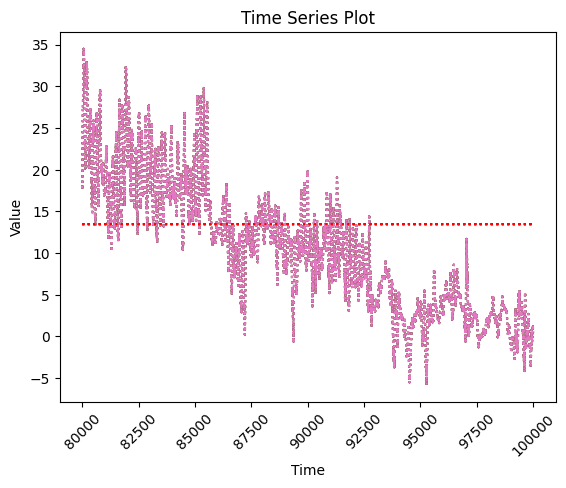

In [42]:
# vary number of ancilla qubits and observables
# the expectation is that more qubits in the reservoir are able to produce more involved dynamics

# author info (citation)
# Source code: XYZ

# reload/select best model
file = MODEL_DIR_QRC / "QRC_model_ancilla.pkl"

# create models
for i in range(1,10):
    my_encoder = qe.CHEEncoder(feature_num=1)
    my_encoder.print_circuit()

    my_reservoir = CNOTReservoir(my_encoder,
                             ancilla_num=i,
                             depth=1)

    my_observables = [Observable(1) for _ in range(i)]

    QRC_model = RCModel(reservoir=my_reservoir,
                        observables=my_observables,
                        subestimator=LinearRegression())

    evaluate_model(QRC_model, train, test)
# CONCLUSION: the number of ancilla qubits doesn't play a role just by itself

   ___   
  |RZ |  
--|   |--
  |___|  
Mean error: 7.218187120175095
Standard deviation: 8.623967877643375


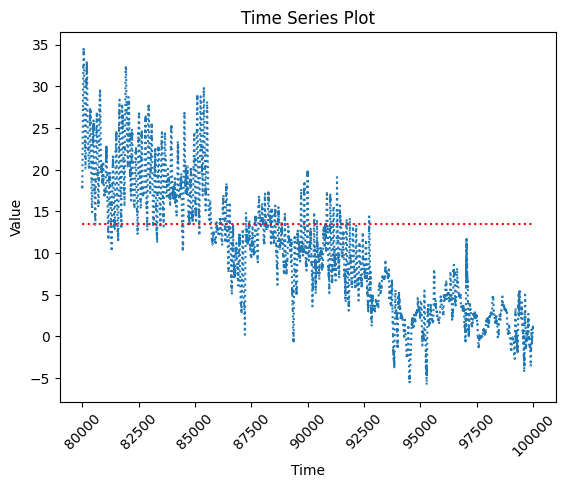

Mean error: 6.965234959793091
Standard deviation: 7.713226141431567


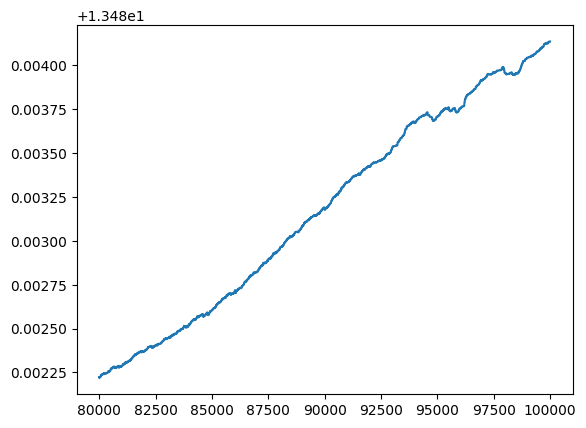

In [49]:
# no variation in ancilla qubits, but make the observables more involved

# reload/select best model
file = MODEL_DIR_QRC / "QRC_model_ancilla_and_observables.pkl"

my_encoder = qe.CHEEncoder(feature_num=1)
my_encoder.print_circuit()

my_reservoir = CNOTReservoir(my_encoder,
                             ancilla_num=2,
                             depth=1)

# inspiration (and most of implementation) taken from qreservoir usage example on
# https://owenagnel.github.io/qreservoir/qreservoir.html#example
my_observables = [Observable(3) for _ in range(2)]

for i, ob in enumerate(my_observables[0::3]):
    ob.add_operator(1.0, f"X {i}")
for i, ob in enumerate(my_observables[1::3]):
    ob.add_operator(1.0, f"Z {i}")
for i, ob in enumerate(my_observables[2::3]):
    ob.add_operator(1.0, f"Y {i}")

QRC_model = RCModel(reservoir=my_reservoir,
                    observables=my_observables,
                    subestimator=LinearRegression())

predictions, _, _ = evaluate_model(QRC_model, train, test)

plt.plot(test.index, predictions)
plt.show()

#CONCLUSION: at least not a constant anymore. -> do the same for other ancilla/observable combinations


# for i in range(1,10):
#     my_encoder = qe.CHEEncoder(feature_num=1)
#     my_encoder.print_circuit()
#
#     my_reservoir = CNOTReservoir(my_encoder,
#                              ancilla_num=i,
#                              depth=1)
#
#     # inspiration (and most of implementation) taken from qreservoir usage example on
#     # https://owenagnel.github.io/qreservoir/qreservoir.html#example
#     my_observables = [Observable(3) for _ in range(i)]
#
#     for i, ob in enumerate(my_observables[0::3]):
#         ob.add_operator(1.0, f"X {i}")
#     for i, ob in enumerate(my_observables[1::3]):
#         ob.add_operator(1.0, f"Z {i}")
#     for i, ob in enumerate(my_observables[2::3]):
#         ob.add_operator(1.0, f"Y {i}")
#
#     QRC_model = RCModel(reservoir=my_reservoir,
#                         observables=my_observables,
#                         subestimator=LinearRegression())
#
#     evaluate_model(QRC_model, train, test)


In [50]:
print(predictions)

[[13.4822216 ]
 [13.4822216 ]
 [13.48222256]
 ...
 [13.48413181]
 [13.48413181]
 [13.48413181]]


Mean error: 7.218187120175095
Standard deviation: 8.623967877643375


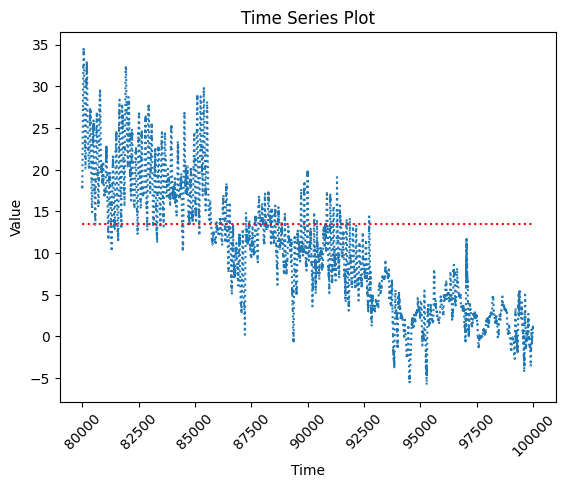

Mean error: 6.965234959793091
Standard deviation: 7.713226141431567


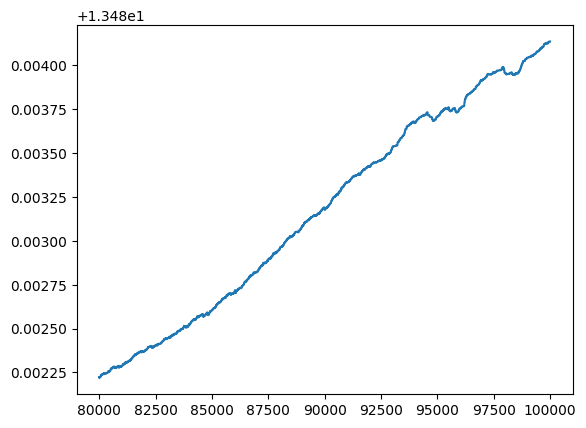

In [51]:
my_reservoir = CNOTReservoir(my_encoder,
                             ancilla_num=3,
                             depth=1)

# inspiration (and most of implementation) taken from qreservoir usage example on
# https://owenagnel.github.io/qreservoir/qreservoir.html#example
my_observables = [Observable(3) for _ in range(3)]

for i, ob in enumerate(my_observables[0::3]):
    ob.add_operator(1.0, f"X {i}")
for i, ob in enumerate(my_observables[1::3]):
    ob.add_operator(1.0, f"Z {i}")
for i, ob in enumerate(my_observables[2::3]):
    ob.add_operator(1.0, f"Y {i}")

QRC_model = RCModel(reservoir=my_reservoir,
                    observables=my_observables,
                    subestimator=LinearRegression())

predictions, _, _ = evaluate_model(QRC_model, train, test)

plt.plot(test.index, predictions)
plt.show()

In [52]:
print(predictions)

[[13.4822216 ]
 [13.4822216 ]
 [13.48222256]
 ...
 [13.48413181]
 [13.48413181]
 [13.48413181]]


Mean error: 7.218187120175095
Standard deviation: 8.623967877643375


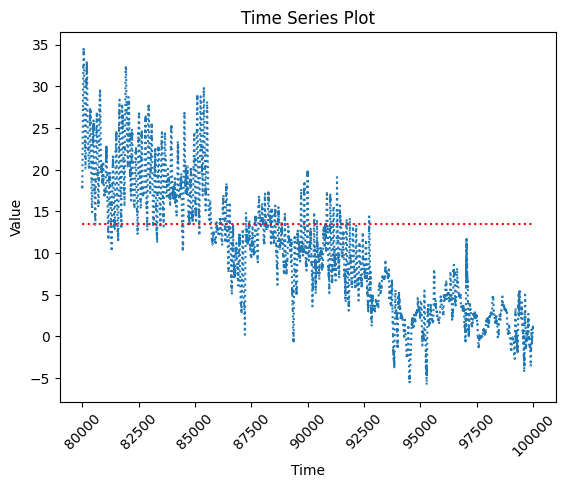

Mean error: 6.965234959793091
Standard deviation: 7.713226141431567


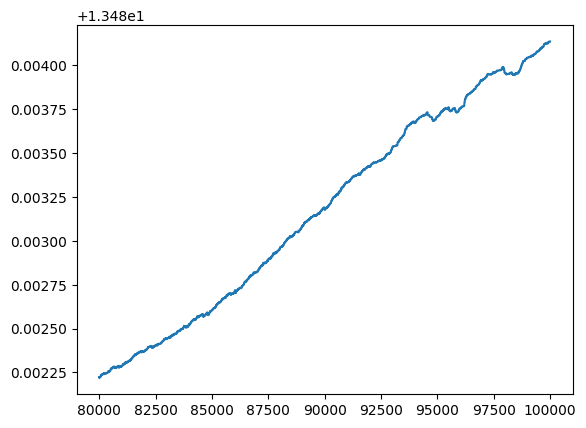

In [53]:
my_reservoir = CNOTReservoir(my_encoder,
                             ancilla_num=4,
                             depth=1)

# inspiration (and most of implementation) taken from qreservoir usage example on
# https://owenagnel.github.io/qreservoir/qreservoir.html#example
my_observables = [Observable(3) for _ in range(4)]

for i, ob in enumerate(my_observables[0::3]):
    ob.add_operator(1.0, f"X {i}")
for i, ob in enumerate(my_observables[1::3]):
    ob.add_operator(1.0, f"Z {i}")
for i, ob in enumerate(my_observables[2::3]):
    ob.add_operator(1.0, f"Y {i}")

QRC_model = RCModel(reservoir=my_reservoir,
                    observables=my_observables,
                    subestimator=LinearRegression())

predictions, _, _ = evaluate_model(QRC_model, train, test)

plt.plot(test.index, predictions)
plt.show()

In [54]:
print(predictions)
# CONCLUSION: doesn't seem to yield different results.

[[13.4822216 ]
 [13.4822216 ]
 [13.48222256]
 ...
 [13.48413181]
 [13.48413181]
 [13.48413181]]
